# Prototypical Networks — Few-Shot Gesture Classification

Implements the **N-way K-shot Prototypical Network** from Snell et al. 2017,  
as covered in Stanford CS330 Lecture 6 (Non-Parametric Few-Shot Learning).

Architecture mirrors the existing `KerasMultiBranchClassifier` backbone —  
multi-branch 1D CNN + attention fusion — but **without a classification head**.  
Instead a projection to an L2-normalised embedding space is appended.  
Classification is done at inference time via nearest-prototype Euclidean distance.

**Key design choices**  
- No inner-loop gradient steps (unlike MAML) — just a forward pass per episode  
- Permutation-invariant prototype computation (mean over support embeddings)  
- Fixed Euclidean distance metric; the encoder learns the metric space  
- Gradient batching over `batch_episodes` episodes before each optimiser step  
- Early stopping on episodic validation accuracy


In [1]:
import os
import warnings
import logging
import tensorflow as tf

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["ABSL_LOG_LEVEL"] = "3"

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")
logging.getLogger("tensorflow").setLevel(logging.ERROR)

from __future__ import annotations

import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder

import sys
sys.path.append('/kaggle/input/datasets/keithmarange/protostuffaha/')
sys.path.append('/kaggle/input/cmi-competition-code')

import data_utils
import utils_multitask_hardsharing as utils  # existing pipeline utils
import utils_proto                           # Prototypical Network utils


2026-05-31 15:01:36.193933: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780239696.415042      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780239696.485021      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780239697.009611      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780239697.009656      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780239697.009659      24 computation_placer.cc:177] computation placer alr

## Config

In [2]:
random_state    = 42
primary_target  = "gesture"

# Episode hyperparameters
N_WAY           = 18    # number of classes per episode (set to your gesture count)
K_SHOT          = 5     # support examples per class
N_QUERY         = 5     # query examples per class
EPISODES_PER_EPOCH = 200
META_EPOCHS     = 100
PATIENCE        = 10
LEARNING_RATE   = 5e-5
BATCH_EPISODES  = 4     # gradient accumulation over this many episodes

# Encoder
MAXLEN          = 160
EMBED_DIM       = 256
FUSION_MODE     = "attention"  # "attention" | "bigru" | "none"

# Train/val/test split
VAL_FRACTION    = 0.15
TEST_FRACTION   = 0.15

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)
timestamp   = datetime.now().strftime("%Y%m%d_%H%M")


## Load data

In [3]:
data_root = data_utils.find_data_root()

raw_train_df   = pd.read_csv(data_root / "train.csv")
train_demo_df  = pd.read_csv(data_root / "train_demographics.csv")

print("raw_train_df :", raw_train_df.shape)
print("train_demo_df:", train_demo_df.shape)


Using Kaggle data folder: /kaggle/input/competitions/cmi-detect-behavior-with-sensor-data
raw_train_df : (574945, 341)
train_demo_df: (81, 8)


## Build labels DataFrame

In [4]:
# ============================================================
# Base dataframe + helper targets
# ============================================================

train_df = raw_train_df.set_index("row_id").copy(deep=True)

train_df.loc[:, "gesture_position"] = train_df["gesture"].str.split(" - ").str[0]
train_df.loc[:, "gesture_action"] = train_df["gesture"].str.split(" - ").str[-1]
train_df.loc[:, "is_target"] = train_df["sequence_type"].eq("Target").astype(int)
train_df.loc[:, "phase_target"] = train_df["phase"]
train_df.loc[:, "orientation_action"] = train_df["orientation"].astype(str) + "||" + train_df["gesture_action"].astype(str)

print("all sequences:", train_df["sequence_id"].nunique())
print("target sequences:", train_df.loc[train_df["sequence_type"].eq("Target"), "sequence_id"].nunique())
print("gesture_action classes:", sorted(train_df.loc[train_df["sequence_type"].eq("Target"), "gesture_action"].dropna().unique()))
print("orientation classes:", sorted(train_df.loc[train_df["sequence_type"].eq("Target"), "orientation"].dropna().unique()))
print("gesture_position classes:", sorted(train_df.loc[train_df["sequence_type"].eq("Target"), "gesture_position"].dropna().unique()))
print("full gesture classes:", sorted(train_df.loc[train_df["sequence_type"].eq("Target"), "gesture"].dropna().unique()))


all sequences: 8151
target sequences: 5113
gesture_action classes: ['pinch skin', 'pull hair', 'pull hairline', 'scratch']
orientation classes: ['Lie on Back', 'Lie on Side - Non Dominant', 'Seated Lean Non Dom - FACE DOWN', 'Seated Straight']
gesture_position classes: ['Above ear', 'Cheek', 'Eyebrow', 'Eyelash', 'Forehead', 'Neck']
full gesture classes: ['Above ear - pull hair', 'Cheek - pinch skin', 'Eyebrow - pull hair', 'Eyelash - pull hair', 'Forehead - pull hairline', 'Forehead - scratch', 'Neck - pinch skin', 'Neck - scratch']


## Subject-aware train / val / test split

Split at **subject level** so no subject leaks across folds.

In [5]:
# ============================================================
# Create label_df (one row per sequence with labels)
# ============================================================

# Create sequence-level metadata with labels
label_df = (
    train_df
    .drop_duplicates("sequence_id")
    [[
        "sequence_id", 
        "subject",           # Note: your column might be "subject" not "subject_id"
        "sequence_type",
        "gesture", 
        "gesture_action", 
        "gesture_position", 
        "orientation",
        "is_target"
    ]]
    .reset_index(drop=True)
    .copy()
)

# Rename if your column is "subject" (not "subject_id")
# If your column is actually "subject_id", change the column name above

print(f"label_df shape: {label_df.shape}")
print(f"Unique sequences: {label_df['sequence_id'].nunique()}")
print(f"Unique subjects: {label_df['subject'].nunique()}")

label_df shape: (8151, 8)
Unique sequences: 8151
Unique subjects: 81


In [6]:
# ============================================================
# Subject-based split
# ============================================================

TEST_FRACTION = 0.15   # 15% for test
VAL_FRACTION = 0.15    # 15% for validation

all_sequence_ids = label_df["sequence_id"].unique()

# Map sequence_id to subject (using the label_df)
seq_to_subject = dict(zip(label_df["sequence_id"], label_df["subject"]))

subjects = [seq_to_subject[sid] for sid in all_sequence_ids]

rng = np.random.default_rng(random_state)
unique_subjects = np.unique(subjects)
rng.shuffle(unique_subjects)

n_test = max(1, int(len(unique_subjects) * TEST_FRACTION))
n_val  = max(1, int(len(unique_subjects) * VAL_FRACTION))

test_subjects  = set(unique_subjects[:n_test])
val_subjects   = set(unique_subjects[n_test : n_test + n_val])
train_subjects = set(unique_subjects[n_test + n_val :])

# Get sequence IDs for each split
train_seq_ids = label_df[label_df["subject"].isin(train_subjects)]["sequence_id"].values
val_seq_ids   = label_df[label_df["subject"].isin(val_subjects)]["sequence_id"].values
test_seq_ids  = label_df[label_df["subject"].isin(test_subjects)]["sequence_id"].values

print(f"Train subjects: {len(train_subjects)}")
print(f"Val subjects: {len(val_subjects)}")
print(f"Test subjects: {len(test_subjects)}")
print(f"Train seqs: {len(train_seq_ids)}")
print(f"Val seqs: {len(val_seq_ids)}")
print(f"Test seqs: {len(test_seq_ids)}")

Train subjects: 57
Val subjects: 12
Test subjects: 12
Train seqs: 5704
Val seqs: 1223
Test seqs: 1224


## Feature extraction

Uses the same `SequenceExtractor` pipeline as the existing multi-task notebook.

In [7]:
pipe = Pipeline([
    ("sequence_builder", utils.AdvancedMultiDomainSequenceExtractor(
        acc_mode="raw",
        rotation_mode="quaternion",
        linear_acc_mode="baseline",
        use_acc_magnitude=True,
        tof_mode="pooled",
        thm_mode="centered",
        standardize="mean_std",
        # maxlen=MAXLEN,
        sequence_col="sequence_id",
    )),
])

# Fit on ALL training rows then transform each split
train_rows = raw_train_df[raw_train_df["sequence_id"].isin(train_seq_ids)]
val_rows   = raw_train_df[raw_train_df["sequence_id"].isin(val_seq_ids)]
test_rows  = raw_train_df[raw_train_df["sequence_id"].isin(test_seq_ids)]

pipe.fit(train_rows, label_df)

X_train_feat = pipe.transform(train_rows)
X_val_feat   = pipe.transform(val_rows)
X_test_feat  = pipe.transform(test_rows)

print("X_train_feat:", X_train_feat.shape, "| index=sequence_id")
print("X_val_feat  :", X_val_feat.shape)
print("X_test_feat :", X_test_feat.shape)


X_train_feat: (403044, 61) | index=sequence_id
X_val_feat  : (83034, 61)
X_test_feat : (88867, 61)


## Label DataFrames per split

In [8]:
y_train = label_df[label_df["sequence_id"].isin(train_seq_ids)].copy()
y_val   = label_df[label_df["sequence_id"].isin(val_seq_ids)].copy()
y_test  = label_df[label_df["sequence_id"].isin(test_seq_ids)].copy()

print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)


y_train: (5704, 8)
y_val  : (1223, 8)
y_test : (1224, 8)


## Build & meta-train the Prototypical Network

In [9]:
proto_clf = utils_proto.KerasPrototypicalClassifier(
    target=primary_target,
    maxlen=MAXLEN,
    padding_value=-999.0,

    # Encoder architecture (matches KerasMultiBranchClassifier defaults)
    branch_filters=       {"acc": "512-512", "rot": "512-512", "tof": "256", "thm": "64"},
    branch_kernel_sizes=  {"acc": "3-3",    "rot": "3-3",   "tof": "3",  "thm": "3"},
    branch_pool_sizes=    {"acc": "2-2", "rot": "2-2", "tof": "2", "thm": "none"},
    fusion_mode=FUSION_MODE,
    attention_heads=10,
    gru_units=128,
    use_batch_norm=True,
    spatial_dropout=0.01,
    embed_dim=EMBED_DIM,
    dropout=0.01,

    # Episode hyperparameters
    n_way=N_WAY,
    k_shot=K_SHOT,
    n_query=N_QUERY,
    episodes_per_epoch=EPISODES_PER_EPOCH,
    meta_epochs=META_EPOCHS,
    patience=PATIENCE,
    learning_rate=LEARNING_RATE,
    batch_episodes=BATCH_EPISODES,
    val_fraction=VAL_FRACTION,
    verbose=1,
    random_state=random_state,
)


In [10]:
proto_clf.fit(X_train_feat, y_train)
print(f"\nBest episodic val accuracy: {proto_clf.best_val_acc_:.4f}")


I0000 00:00:1780239868.714548      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780239868.720478      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1780239870.403403      24 cuda_dnn.cc:529] Loaded cuDNN version 91002


Epoch   1/100  train_loss=2.4234  train_acc=0.2994  val_loss=2.3922  val_acc=0.2951
Epoch   2/100  train_loss=2.1144  train_acc=0.3793  val_loss=2.1328  val_acc=0.3760
Epoch   3/100  train_loss=2.0211  train_acc=0.4151  val_loss=2.0788  val_acc=0.3851
Epoch   4/100  train_loss=2.0150  train_acc=0.4241  val_loss=2.0798  val_acc=0.3822
Epoch   5/100  train_loss=1.9867  train_acc=0.4192  val_loss=2.0325  val_acc=0.3958
Epoch   6/100  train_loss=1.9810  train_acc=0.4109  val_loss=2.1823  val_acc=0.3422
Epoch   7/100  train_loss=1.9899  train_acc=0.4002  val_loss=2.0535  val_acc=0.3598
Epoch   8/100  train_loss=1.9570  train_acc=0.4038  val_loss=2.0400  val_acc=0.3789
Epoch   9/100  train_loss=2.0036  train_acc=0.3913  val_loss=2.1137  val_acc=0.3527
Epoch  10/100  train_loss=1.9563  train_acc=0.4015  val_loss=2.1451  val_acc=0.3522
Epoch  11/100  train_loss=1.9624  train_acc=0.3966  val_loss=2.0259  val_acc=0.3709
Epoch  12/100  train_loss=1.9529  train_acc=0.4032  val_loss=2.0234  val_acc

## Training curves

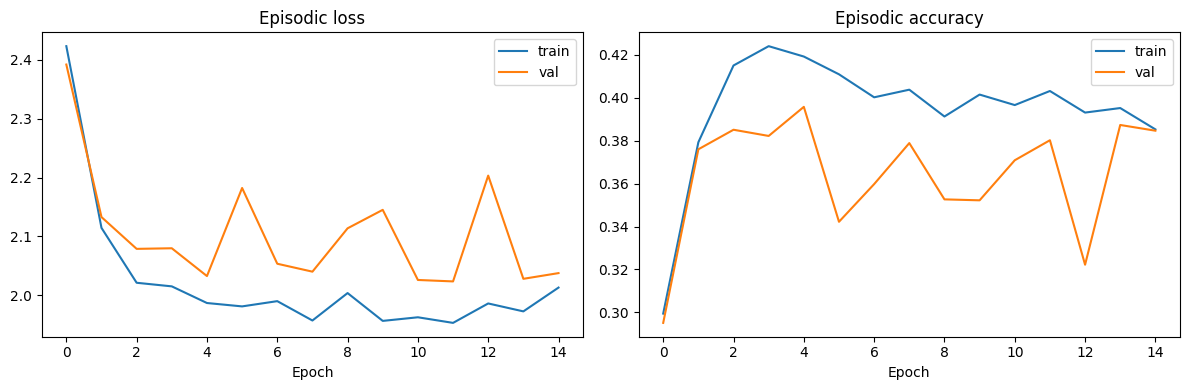

In [11]:
import matplotlib.pyplot as plt

hist = proto_clf.history_
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist["train_loss"], label="train")
axes[0].plot(hist["val_loss"],   label="val")
axes[0].set_title("Episodic loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(hist["train_acc"], label="train")
axes[1].plot(hist["val_acc"],   label="val")
axes[1].set_title("Episodic accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(results_dir / f"proto_training_curves_{timestamp}.png", dpi=120)
plt.show()


## Evaluation on held-out test set

**Prototypical inference** requires a support set.  
We use the **validation set** as the support set and the test set as queries.  
This mirrors the meta-test setup from CS330 Lecture 6:

```
compute prototypes from support set → classify queries by nearest prototype
```


In [12]:
# Build prototypes from validation support set
proto_clf.fit_support(X_val_feat, y_val)

# Predict on test queries
y_pred_test = proto_clf.predict(X_test_feat)

# Ground-truth labels (one per test sequence)
X_test_pad, test_seq_ids = proto_clf._pad(X_test_feat)
y_test_seq = proto_clf._collapse_y(test_seq_ids, y_test)

f1_macro = f1_score(y_test_seq, y_pred_test, average="macro")
print(f"Test macro-F1: {f1_macro:.4f}")
print()
print(classification_report(y_test_seq, y_pred_test))


I0000 00:00:1780241186.492509      70 service.cc:152] XLA service 0x7a2dad105e60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780241186.492552      70 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780241186.492556      70 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780241187.852736      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Test macro-F1: 0.3543

                                            precision    recall  f1-score   support

                     Above ear - pull hair       0.04      0.02      0.03        96
                        Cheek - pinch skin       0.19      0.78      0.31        96
                     Drink from bottle/cup       0.86      0.50      0.63        24
                       Eyebrow - pull hair       0.22      0.11      0.15        96
                       Eyelash - pull hair       0.09      0.03      0.05        96
Feel around in tray and pull out an object       0.50      0.92      0.65        24
                  Forehead - pull hairline       0.27      0.15      0.19        96
                        Forehead - scratch       0.39      0.69      0.49        96
                            Glasses on/off       0.83      0.79      0.81        24
                         Neck - pinch skin       0.23      0.03      0.06        96
                            Neck - scratch       0.0

## K-shot ablation

One of the key benefits of Prototypical Networks is that you can vary K at inference time  
without retraining — the encoder is fixed; only the prototype computation changes.


In [13]:
from sklearn.model_selection import StratifiedShuffleSplit

le = proto_clf.le_
y_val_enc = le.transform(proto_clf._collapse_y(
    proto_clf._pad(X_val_feat)[1], y_val
))

X_val_pad, val_seq_ids = proto_clf._pad(X_val_feat)
val_embeddings = proto_clf.encoder_.predict(X_val_pad, verbose=0)

results_kshot = {}
for k in [1, 2, 5, 10, "all"]:
    if k == "all":
        sub_emb = val_embeddings
        sub_labels = y_val_enc
    else:
        rng_k = np.random.default_rng(42)
        sub_idx = []
        for cls in range(len(proto_clf.classes_)):
            cls_idx = np.flatnonzero(y_val_enc == cls)
            chosen = rng_k.choice(cls_idx, size=min(k, len(cls_idx)), replace=False)
            sub_idx.extend(chosen.tolist())
        sub_emb    = val_embeddings[sub_idx]
        sub_labels = y_val_enc[sub_idx]

    proto_clf.prototypes_ = proto_clf._compute_prototypes(sub_emb, sub_labels)

    y_pred_k = proto_clf.predict(X_test_feat)
    f1_k = f1_score(y_test_seq, y_pred_k, average="macro")
    results_kshot[k] = f1_k
    print(f"K={str(k):>4}  macro-F1 = {f1_k:.4f}")

# Restore full support
proto_clf.fit_support(X_val_feat, y_val)


K=   1  macro-F1 = 0.2489
K=   2  macro-F1 = 0.3191
K=   5  macro-F1 = 0.3339
K=  10  macro-F1 = 0.3209
K= all  macro-F1 = 0.3543


KerasPrototypicalClassifier(attention_heads=10,
                            branch_filters={'acc': '512-512', 'rot': '512-512',
                                            'thm': '64', 'tof': '256'},
                            branch_kernel_sizes={'acc': '3-3', 'rot': '3-3',
                                                 'thm': '3', 'tof': '3'},
                            branch_pool_sizes={'acc': '2-2', 'rot': '2-2',
                                               'thm': 'none', 'tof': '2'},
                            dropout=0.01, embed_dim=256, learning_rate=5e-05,
                            maxlen=160, meta_epochs=100, n_way=18,
                            spatial_dropout=0.01, target='gesture')

## Embedding space visualisation (UMAP)

If `umap-learn` is not available this cell is skipped.

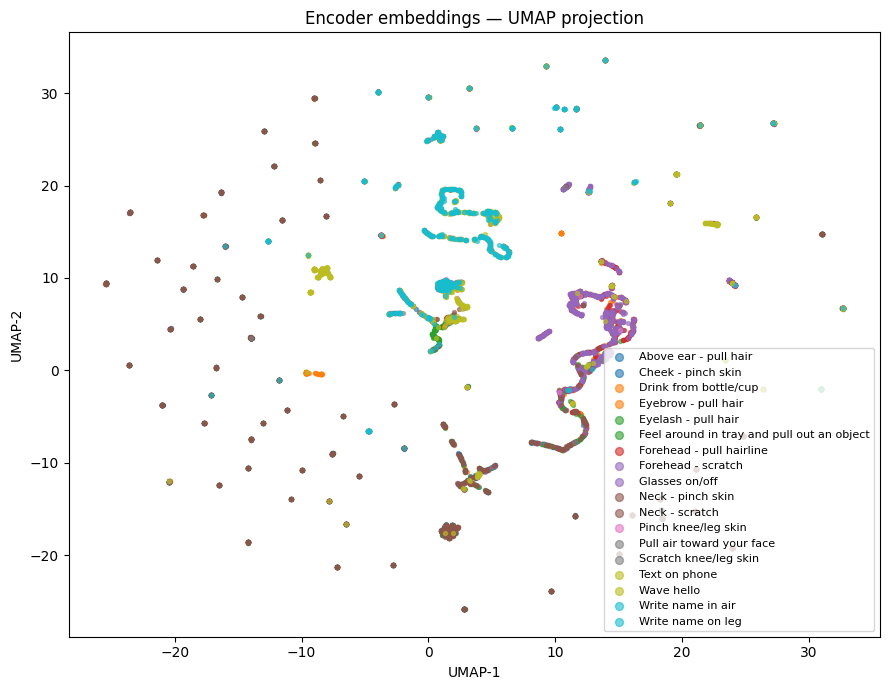

In [14]:
try:
    import umap

    X_all_pad, all_seq_ids = proto_clf._pad(
        pd.concat([X_train_feat, X_val_feat, X_test_feat])
    )
    all_emb = proto_clf.encoder_.predict(X_all_pad, verbose=0)

    all_y = pd.concat([
        proto_clf._collapse_y(proto_clf._pad(X_train_feat)[1], y_train),
        proto_clf._collapse_y(proto_clf._pad(X_val_feat)[1],   y_val),
        proto_clf._collapse_y(proto_clf._pad(X_test_feat)[1],  y_test),
    ]).reset_index(drop=True)

    reducer = umap.UMAP(n_components=2, random_state=random_state, n_neighbors=15)
    emb_2d  = reducer.fit_transform(all_emb)

    classes_unique = proto_clf.classes_
    cmap = plt.cm.get_cmap("tab10", len(classes_unique))

    fig, ax = plt.subplots(figsize=(9, 7))
    for i, cls in enumerate(classes_unique):
        mask = all_y == cls
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                   s=8, alpha=0.6, color=cmap(i), label=cls)
    ax.legend(markerscale=2, fontsize=8)
    ax.set_title("Encoder embeddings — UMAP projection")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    plt.tight_layout()
    plt.savefig(results_dir / f"proto_umap_{timestamp}.png", dpi=120)
    plt.show()

except ImportError:
    print("umap-learn not installed — skipping visualisation. pip install umap-learn")


## Save encoder weights

In [15]:
weights_path = results_dir / f"proto_encoder_{timestamp}.weights.h5"
proto_clf.encoder_.save_weights(str(weights_path))
print(f"Encoder weights saved to {weights_path}")

# Save label encoder classes for later inference
np.save(
    results_dir / f"proto_classes_{timestamp}.npy",
    proto_clf.classes_,
)
print("Label encoder classes saved.")


Encoder weights saved to results/proto_encoder_20260531_1501.weights.h5
Label encoder classes saved.
